In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

In [2]:
user_columns = [

    "user_id",

    "age",

    "gender",

    "occupation",

    "zip_code"

]

users = pd.read_csv(

    "../data/u.user",

    sep="|",

    names=user_columns

)

In [3]:
users["user_id"] -= 1
users.head()

,user_id,age,gender,occupation,zip_code
0,0,24,M,technician,85711
1,1,53,F,other,94043
2,2,23,M,writer,32067
3,3,24,M,technician,43537
4,4,33,F,other,15213


In [4]:
column_names = [
    "user_id",
    "movie_id",
    "rating",
    "timestamp"
]

train = pd.read_csv(
    "../data/u1.base",
    sep="\t",
    names=column_names
)

test = pd.read_csv(
    "../data/u1.test",
    sep="\t",
    names=column_names
)

In [5]:
train = train.merge(

    users,

    on="user_id"

)

test = test.merge(

    users,

    on="user_id"

)
train.head()

,user_id,movie_id,rating,timestamp,age,gender,occupation,zip_code
0,1,1,5,874965758,53,F,other,94043
1,1,2,3,876893171,53,F,other,94043
2,1,3,4,878542960,53,F,other,94043
3,1,4,3,876893119,53,F,other,94043
4,1,5,3,889751712,53,F,other,94043


In [6]:
movie_columns = [

    "movie_id",

    "title",

    "release_date",

    "video_release",

    "IMDb"

]

genre_columns = [

    "unknown",

    "Action",

    "Adventure",

    "Animation",

    "Children",

    "Comedy",

    "Crime",

    "Documentary",

    "Drama",

    "Fantasy",

    "Film-Noir",

    "Horror",

    "Musical",

    "Mystery",

    "Romance",

    "Sci-Fi",

    "Thriller",

    "War",

    "Western"

]

movie_columns += genre_columns

movies = pd.read_csv(

    "../data/u.item",

    sep="|",

    encoding="latin-1",

    names=movie_columns
)

movies["movie_id"] -= 1

In [7]:
train = train.merge(

    movies,

    on="movie_id"

)

test = test.merge(

    movies,

    on="movie_id"

)

In [8]:
train.head()

,user_id,movie_id,rating,timestamp,age,gender,occupation,zip_code,title,release_date,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,1,5,874965758,53,F,other,94043,GoldenEye (1995),01-Jan-1995,...,0,0,0,0,0,0,0,1,0,0
1,1,2,3,876893171,53,F,other,94043,Four Rooms (1995),01-Jan-1995,...,0,0,0,0,0,0,0,1,0,0
2,1,3,4,878542960,53,F,other,94043,Get Shorty (1995),01-Jan-1995,...,0,0,0,0,0,0,0,0,0,0
3,1,4,3,876893119,53,F,other,94043,Copycat (1995),01-Jan-1995,...,0,0,0,0,0,0,0,1,0,0
4,1,5,3,889751712,53,F,other,94043,Shanghai Triad (Yao a yao yao dao waipo qiao) ...,01-Jan-1995,...,0,0,0,0,0,0,0,0,0,0


In [9]:
train.columns

Index(['user_id', 'movie_id', 'rating', 'timestamp', 'age', 'gender',
       'occupation', 'zip_code', 'title', 'release_date', 'video_release',
       'IMDb', 'unknown', 'Action', 'Adventure', 'Animation', 'Children',
       'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir',
       'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War',
       'Western'],
      dtype='str')

In [10]:
gender_to_idx = {
    gender: idx
    for idx, gender in enumerate(
        users["gender"].unique()
    )
}

users["gender_idx"] = users["gender"].map(
    gender_to_idx
)

In [11]:
occupation_to_idx = {
    occupation: idx
    for idx, occupation in enumerate(
        users["occupation"].unique()
    )
}

users["occupation_idx"] = users["occupation"].map(
    occupation_to_idx
)

In [12]:
train = train.drop(
    columns=[
        "age",
        "gender",
        "occupation",
        "zip_code"
    ]
)

test = test.drop(
    columns=[
        "age",
        "gender",
        "occupation",
        "zip_code"
    ]
)

train = train.merge(
    users,
    on="user_id"
)

test = test.merge(
    users,
    on="user_id"
)

In [13]:
train["age"] = (
    train["age"] / train["age"].max()
)

test["age"] = (
    test["age"] / test["age"].max()
)

In [14]:
train['label'] = train['rating'].apply(lambda x: 1 if x >= 3 else 0)
test['label'] = test['rating'].apply(lambda x: 1 if x >= 3 else 0)

In [15]:
train.head()

,user_id,movie_id,rating,timestamp,title,release_date,video_release,IMDb,unknown,Action,...,Thriller,War,Western,age,gender,occupation,zip_code,gender_idx,occupation_idx,label
0,1,1,5,874965758,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,...,1,0,0,0.726027,F,other,94043,1,1,1
1,1,2,3,876893171,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,...,1,0,0,0.726027,F,other,94043,1,1,1
2,1,3,4,878542960,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,...,0,0,0,0.726027,F,other,94043,1,1,1
3,1,4,3,876893119,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,...,1,0,0,0.726027,F,other,94043,1,1,1
4,1,5,3,889751712,Shanghai Triad (Yao a yao yao dao waipo qiao) ...,01-Jan-1995,NaN,http://us.imdb.com/Title?Yao+a+yao+yao+dao+wai...,0,0,...,0,0,0,0.726027,F,other,94043,1,1,1


In [16]:
from torch.utils.data import Dataset

class RankingDataset(Dataset):

    def __init__(self, dataframe):

        self.user_id = torch.LongTensor(
            dataframe["user_id"].values
        )

        self.movie_id = torch.LongTensor(
            dataframe["movie_id"].values
        )

        self.gender = torch.LongTensor(
            dataframe["gender_idx"].values
        )

        self.occupation = torch.LongTensor(
            dataframe["occupation_idx"].values
        )

        self.age = torch.FloatTensor(
            dataframe["age"].values
        )

        self.genres = torch.FloatTensor(
            dataframe[genre_columns].values
        )

        self.labels = torch.FloatTensor(
            dataframe["label"].values
        )

    def __len__(self):

        return len(self.labels)

    def __getitem__(self, idx):

        return (

            self.user_id[idx],

            self.movie_id[idx],

            self.gender[idx],

            self.occupation[idx],

            self.age[idx],

            self.genres[idx],

            self.labels[idx]

        )

In [17]:
train_dataset = RankingDataset(
    train
)

test_dataset = RankingDataset(
    test
)

C:\Users\miyas\AppData\Local\Temp\ipykernel_19596\432480342.py:7: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  self.user_id = torch.LongTensor(


In [18]:
from torch.utils.data import DataLoader

train_loader = DataLoader(

    train_dataset,

    batch_size=512,

    shuffle=True

)

test_loader = DataLoader(

    test_dataset,

    batch_size=512,

    shuffle=False

)

In [19]:
batch = next(
    iter(train_loader)
)

for tensor in batch:

    print(tensor.shape)

torch.Size([512])
torch.Size([512])
torch.Size([512])
torch.Size([512])
torch.Size([512])
torch.Size([512, 19])
torch.Size([512])


In [20]:
class FeatureEncoder(nn.Module):

    def __init__(

        self,

        num_users,

        num_movies,

        num_genders,

        num_occupations,

        embedding_dim=16

    ):

        super().__init__()

        self.user_embedding = nn.Embedding(

            num_users,

            embedding_dim

        )

        self.movie_embedding = nn.Embedding(

            num_movies,

            embedding_dim

        )

        self.gender_embedding = nn.Embedding(

            num_genders,

            4

        )

        self.occupation_embedding = nn.Embedding(

            num_occupations,

            8

        )

    def forward(

        self,

        user,

        movie,

        gender,

        occupation,

        age,

        genres

    ):

        user = self.user_embedding(
            user
        )

        movie = self.movie_embedding(
            movie
        )

        gender = self.gender_embedding(
            gender
        )

        occupation = self.occupation_embedding(
            occupation
        )

        age = age.unsqueeze(1)

        features = torch.cat(

            [

                user,

                movie,

                gender,

                occupation,

                age,

                genres

            ],

            dim=1

        )

        return features

In [21]:
num_users = users["user_id"].nunique()
num_movies = movies["movie_id"].nunique()

In [22]:
encoder = FeatureEncoder(

    num_users=num_users,

    num_movies=num_movies,

    num_genders=len(gender_to_idx),

    num_occupations=len(
        occupation_to_idx
    )

)

In [23]:
batch = next(
    iter(train_loader)
)

features = encoder(

    batch[0],

    batch[1],

    batch[2],

    batch[3],

    batch[4],

    batch[5]

)

print(features.shape)

torch.Size([512, 64])


In [24]:
class RankingModel(nn.Module):

    def __init__(

        self,

        num_users,

        num_movies,

        num_genders,

        num_occupations

    ):

        super().__init__()

        self.encoder = FeatureEncoder(

            num_users,

            num_movies,

            num_genders,

            num_occupations

        )

        self.network = nn.Sequential(

            nn.Linear(64, 128),

            nn.ReLU(),

            nn.Dropout(0.2),

            nn.Linear(128, 64),

            nn.ReLU(),

            nn.Dropout(0.2),

            nn.Linear(64, 1)

        )

    def forward(

        self,

        user,

        movie,

        gender,

        occupation,

        age,

        genres

    ):

        features = self.encoder(

            user,

            movie,

            gender,

            occupation,

            age,

            genres

        )

        logits = self.network(

            features

        )

        return logits.squeeze()

In [25]:
model = RankingModel(

    num_users=num_users,

    num_movies=num_movies,

    num_genders=len(gender_to_idx),

    num_occupations=len(
        occupation_to_idx
    )

)

In [26]:
batch = next(
    iter(train_loader)
)

output = model(

    batch[0],

    batch[1],

    batch[2],

    batch[3],

    batch[4],

    batch[5]

)

print(output.shape)

torch.Size([512])


In [27]:
probabilities = torch.sigmoid(
    output
)

print(
    probabilities[:10]
)

tensor([0.4741, 0.4965, 0.4743, 0.4655, 0.4946, 0.4976, 0.4718, 0.4513, 0.5040,
        0.4968], grad_fn=<SliceBackward0>)


In [28]:
criterion = nn.BCEWithLogitsLoss()

In [29]:
loss = criterion(

    output,

    batch[6]

)

print(loss)

tensor(0.7205, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)


In [30]:
optimizer = torch.optim.Adam(

    model.parameters(),

    lr=0.001

)

In [31]:
def train(

    model,

    train_loader,

    optimizer,

    criterion,

    epochs=20

):

    print("Training Ranking Model...")

    for epoch in range(epochs):

        model.train()

        total_loss = 0.0

        for batch in train_loader:

            (

                user,

                movie,

                gender,

                occupation,

                age,

                genres,

                labels

            ) = batch

            optimizer.zero_grad()

            outputs = model(

                user,

                movie,

                gender,

                occupation,

                age,

                genres

            )

            loss = criterion(

                outputs,

                labels

            )

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        average_loss = (

            total_loss /

            len(train_loader)

        )

        print(

            f"Epoch {epoch+1:2d}/{epochs}"

            f" | Loss = {average_loss:.4f}"

        )

In [32]:
train(

    model,

    train_loader,

    optimizer,

    criterion,

    epochs=20

)

Training Ranking Model...
Epoch  1/20 | Loss = 0.4711
Epoch  2/20 | Loss = 0.4429
Epoch  3/20 | Loss = 0.4283
Epoch  4/20 | Loss = 0.4139
Epoch  5/20 | Loss = 0.4009
Epoch  6/20 | Loss = 0.3905
Epoch  7/20 | Loss = 0.3804
Epoch  8/20 | Loss = 0.3743
Epoch  9/20 | Loss = 0.3688
Epoch 10/20 | Loss = 0.3627
Epoch 11/20 | Loss = 0.3591
Epoch 12/20 | Loss = 0.3549
Epoch 13/20 | Loss = 0.3514
Epoch 14/20 | Loss = 0.3480
Epoch 15/20 | Loss = 0.3451
Epoch 16/20 | Loss = 0.3428
Epoch 17/20 | Loss = 0.3401
Epoch 18/20 | Loss = 0.3389
Epoch 19/20 | Loss = 0.3360
Epoch 20/20 | Loss = 0.3339


In [33]:
def evaluate(

    model,

    test_loader

):

    model.eval()

    predictions = []

    actuals = []

    with torch.no_grad():

        for batch in test_loader:

            (

                user,

                movie,

                gender,

                occupation,

                age,

                genres,

                labels

            ) = batch

            outputs = model(

                user,

                movie,

                gender,

                occupation,

                age,

                genres

            )

            probs = torch.sigmoid(

                outputs

            )

            predictions.extend(

                probs.cpu().numpy()

            )

            actuals.extend(

                labels.cpu().numpy()

            )

    predictions = np.array(predictions)

    actuals = np.array(actuals)

    binary_predictions = (

        predictions >= 0.5

    ).astype(int)

    accuracy = np.mean(

        binary_predictions == actuals

    )

    return (

        accuracy,

        predictions,

        actuals

    )

In [34]:
accuracy, predictions, labels = evaluate(

    model,

    test_loader

)

print(

    f"Accuracy : {accuracy:.4f}"

)

Accuracy : 0.8400


In [35]:
results = pd.DataFrame(

    {

        "Actual": labels,

        "Probability": predictions,

        "Prediction": (

            predictions >= 0.5

        ).astype(int)

    }

)

results.sample(20)

,Actual,Probability,Prediction
19656,1.0,0.967333,1
7042,1.0,0.901235,1
312,1.0,0.918631,1
10578,1.0,0.825633,1
18828,1.0,0.885124,1
6806,1.0,0.870184,1
3649,1.0,0.873812,1
4304,1.0,0.948691,1
15133,1.0,0.912838,1
13548,1.0,0.897340,1


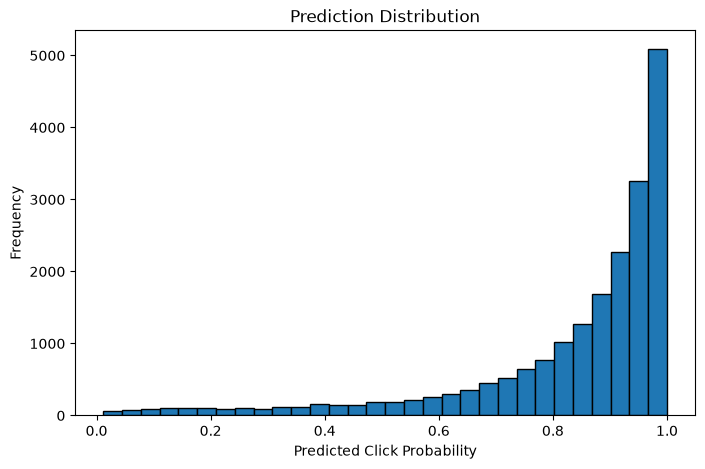

In [36]:
plt.figure(figsize=(8,5))

plt.hist(

    predictions,

    bins=30,

    edgecolor="black"

)

plt.xlabel("Predicted Click Probability")

plt.ylabel("Frequency")

plt.title("Prediction Distribution")

plt.show()

In [37]:
from sklearn.metrics import (

    roc_auc_score,

    roc_curve

)

In [38]:
auc = roc_auc_score(

    labels,

    predictions

)

print(

    f"AUC : {auc:.4f}"

)

AUC : 0.7862


In [39]:
fpr, tpr, thresholds = roc_curve(

    labels,

    predictions

)

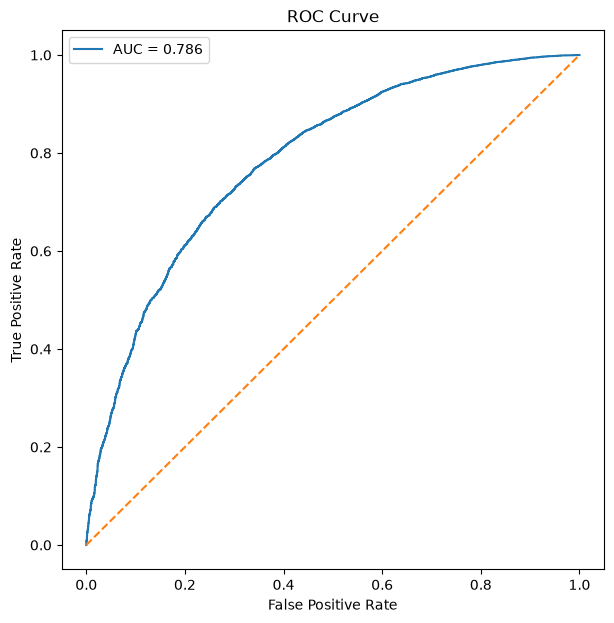

In [40]:
plt.figure(figsize=(7,7))

plt.plot(

    fpr,

    tpr,

    label=f"AUC = {auc:.3f}"

)

plt.plot(

    [0,1],

    [0,1],

    "--"

)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [41]:
prediction_df = test.copy()

prediction_df["score"] = predictions

prediction_df.head()

,user_id,movie_id,rating,timestamp,title,release_date,video_release,IMDb,unknown,Action,...,War,Western,age,gender,occupation,zip_code,gender_idx,occupation_idx,label,score
0,1,6,5,887431973,Twelve Monkeys (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Twelve%20Monk...,0,0,...,0,0,0.779412,F,other,94043,1,1,1,0.683934
1,1,10,3,875693118,Seven (Se7en) (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Se7en%20(1995),0,0,...,0,0,0.779412,F,other,94043,1,1,1,0.895283
2,1,12,5,878542960,Mighty Aphrodite (1995),30-Oct-1995,NaN,http://us.imdb.com/M/title-exact?Mighty%20Aphr...,0,0,...,0,0,0.779412,F,other,94043,1,1,1,0.963219
3,1,14,5,874965706,Mr. Holland's Opus (1995),29-Jan-1996,NaN,http://us.imdb.com/M/title-exact?Mr.%20Holland...,0,0,...,0,0,0.779412,F,other,94043,1,1,1,0.909879
4,1,17,3,875073198,"White Balloon, The (1995)",01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Badkonake%20S...,0,0,...,0,0,0.779412,F,other,94043,1,1,1,0.386408


In [42]:
def precision_at_k(
    prediction_df,
    k=10
):

    precisions = []

    grouped = prediction_df.groupby("user_id")

    for _, group in grouped:

        top_k = group.sort_values(
            "score",
            ascending=False
        ).head(k)

        precision = top_k["label"].mean()

        precisions.append(
            precision
        )

    return np.mean(
        precisions
    )

In [43]:
p10 = precision_at_k(
    prediction_df,
    k=10
)

print(
    f"Precision@10 : {p10:.4f}"
)

Precision@10 : 0.9102


In [44]:
def recall_at_k(
    prediction_df,
    k=10
):

    recalls = []

    grouped = prediction_df.groupby("user_id")

    for _, group in grouped:

        relevant = group["label"].sum()

        if relevant == 0:
            continue

        top_k = group.sort_values(
            "score",
            ascending=False
        ).head(k)

        hits = top_k["label"].sum()

        recalls.append(
            hits / relevant
        )

    return np.mean(
        recalls
    )

In [45]:
r10 = recall_at_k(
    prediction_df,
    k=10
)

print(
    f"Recall@10 : {r10:.4f}"
)

Recall@10 : 0.5092


In [46]:
def hit_rate_at_k(
    prediction_df,
    k=10
):

    hits = []

    grouped = prediction_df.groupby("user_id")

    for _, group in grouped:

        top_k = group.sort_values(
            "score",
            ascending=False
        ).head(k)

        hit = (
            top_k["label"].sum() > 0
        )

        hits.append(hit)

    return np.mean(
        hits
    )

In [47]:
hr10 = hit_rate_at_k(
    prediction_df,
    k=10
)

print(
    f"HitRate@10 : {hr10:.4f}"
)

HitRate@10 : 0.9978


In [48]:
metrics = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "AUC",

        "Precision@10",

        "Recall@10",

        "HitRate@10"

    ],

    "Value":[

        accuracy,

        auc,

        p10,

        r10,

        hr10

    ]

})

metrics

,Metric,Value
0,Accuracy,0.840050
1,AUC,0.786197
2,Precision@10,0.910198
3,Recall@10,0.509198
4,HitRate@10,0.997821
